In [2]:
from scipy.stats import pearsonr
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/Finance_Accounting_Dataset_cleaned.csv')

print('Basic information of the dataset:')
df.info()

# Check the number of rows and columns in the dataset
rows, columns = df.shape

if rows < 100 and columns < 20:
    # For short - form data (less than 100 rows and less than 20 columns), view full data information
    print('Full data information:')
    print(df.to_csv(sep='\t', na_rep='nan'))
else:
    # For long - form data, view the information of the first few rows
    print('Information of the first few rows of data:')
    print(df.head().to_csv(sep='\t', na_rep='nan'))


# Filter small finance companies in Asia
filtered_df = df[(df['Company_Size'] == 'Small') & (df['Industry'] == 'Finance') & (df['Region'] == 'Asia')]

# Calculate the Pearson correlation coefficient and p - value between Market_Cap and Share_Price
corr, p_value = pearsonr(filtered_df['Market_Cap'], filtered_df['Share_Price'])

# Calculate descriptive statistics for Market_Cap and Share_Price
market_cap_stats = filtered_df['Market_Cap'].describe()
share_price_stats = filtered_df['Share_Price'].describe()

# Create a dictionary to store results
results = {
    'Pearson correlation coefficient': corr,
    'p - value': p_value,
    'Market_Cap descriptive statistics': market_cap_stats,
    'Share_Price descriptive statistics': share_price_stats
}

results

<ipython-input-2-f3df2f4c598c>:5: DtypeWarning: Columns (8,9,10,11) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/Finance_Accounting_Dataset_cleaned.csv')


Basic information of the dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Revenue         18053 non-null  float64
 1   Expenses        18053 non-null  float64
 2   Profit          18053 non-null  float64
 3   Assets          18053 non-null  float64
 4   Liabilities     18053 non-null  float64
 5   Debt_Ratio      18053 non-null  float64
 6   Market_Cap      18053 non-null  float64
 7   Share_Price     18053 non-null  float64
 8   Industry        18053 non-null  object 
 9   Region          18053 non-null  object 
 10  Company_Size    18053 non-null  object 
 11  Listing_Status  18053 non-null  object 
dtypes: float64(8), object(4)
memory usage: 96.0+ MB
Information of the first few rows of data:
	Revenue	Expenses	Profit	Assets	Liabilities	Debt_Ratio	Market_Cap	Share_Price	Industry	Region	Company_Size	Listing_Status
0	184

{'Pearson correlation coefficient': np.float64(0.04416260190946872),
 'p - value': np.float64(0.49591928267644697),
 'Market_Cap descriptive statistics': count    2.400000e+02
 mean     9.885360e+06
 std      4.840806e+06
 min      3.525972e+04
 25%      6.512086e+06
 50%      9.284715e+06
 75%      1.296164e+07
 max      2.353810e+07
 Name: Market_Cap, dtype: float64,
 'Share_Price descriptive statistics': count    240.000000
 mean     154.434708
 std       49.140629
 min       17.030000
 25%      120.362500
 50%      160.480000
 75%      186.920000
 max      289.020000
 Name: Share_Price, dtype: float64}

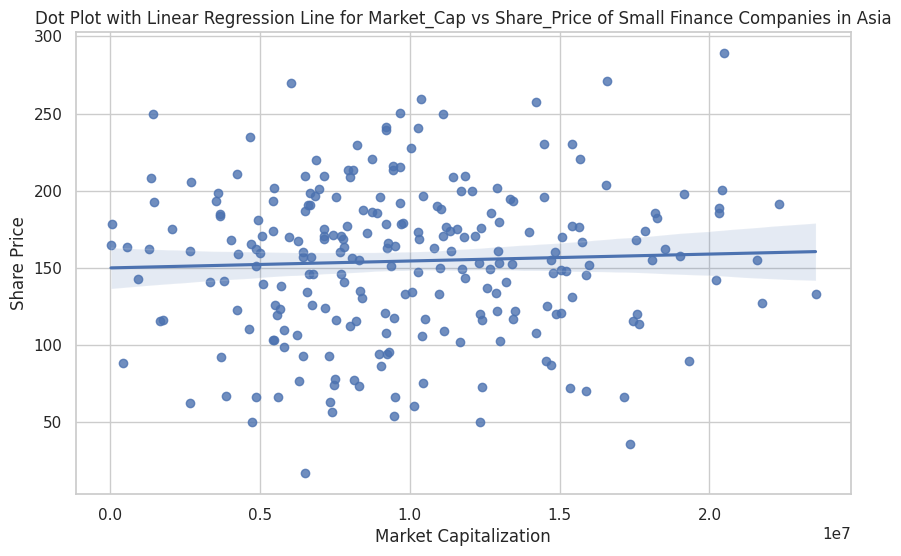

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assume df is the DataFrame loaded from the dataset
# Filter small finance companies in Asia
filtered_df = df[(df['Company_Size'] == 'Small') & (df['Industry'] == 'Finance') & (df['Region'] == 'Asia')]

# Set the style of seaborn
sns.set(style="whitegrid")

# Create a dot plot with a linear regression line
plt.figure(figsize=(10, 6))
sns.regplot(x='Market_Cap', y='Share_Price', data=filtered_df)
plt.title('Dot Plot with Linear Regression Line for Market_Cap vs Share_Price of Small Finance Companies in Asia')
plt.xlabel('Market Capitalization')
plt.ylabel('Share Price')
plt.show()


In [6]:
import pandas as pd

# Assume df is the DataFrame loaded from the dataset
# Group the data by industry and calculate descriptive statistics for the 'Profit' column
profit_stats_by_industry = df.groupby('Industry')['Profit'].describe()

print(profit_stats_by_industry)


                count           mean           std       min          25%  \
Industry                                                                    
Finance        3569.0  197941.109902  49174.142554 -23280.19  164070.0800   
Healthcare     3684.0  197545.314392  50015.190680  23359.09  162646.3200   
Manufacturing  3655.0  198146.225524  49691.217974  27597.85  164468.3950   
Retail         3586.0  199200.335508  49429.073739  40036.77  165632.6975   
Technology     3559.0  197325.275490  50274.258983  28617.22  162329.2750   

                      50%          75%        max  
Industry                                           
Finance        197925.240  230926.2000  367410.36  
Healthcare     197514.425  231521.9675  380567.50  
Manufacturing  198809.810  231747.9650  366763.41  
Retail         198242.690  232589.3050  380120.75  
Technology     197599.860  231319.0150  384581.23  


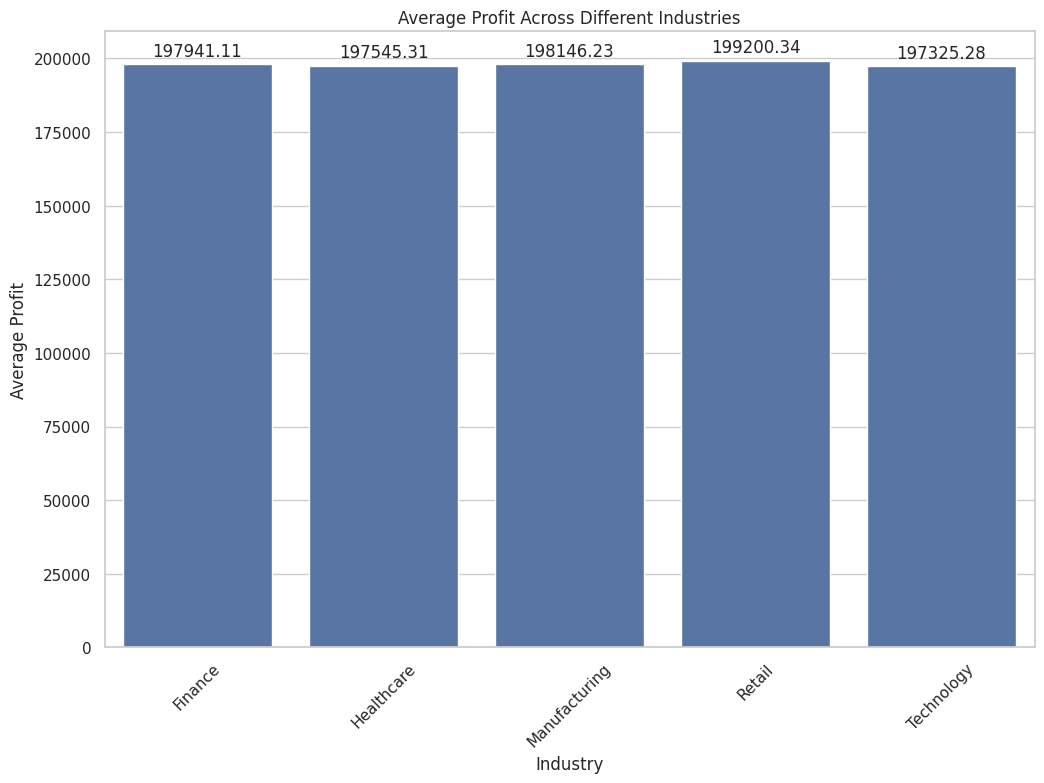

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assume df is the DataFrame loaded from the dataset
# Group the data by industry and calculate the average profit
avg_profit_by_industry = df.groupby('Industry')['Profit'].mean()

# Set the seaborn style
sns.set(style="whitegrid")

# Create a bar chart
plt.figure(figsize=(12, 8))
bars = sns.barplot(x=avg_profit_by_industry.index, y=avg_profit_by_industry.values)

# Add data labels on top of each bar
for bar in bars.patches:
    height = bar.get_height()
    bars.annotate(f'{height:.2f}',
                  xy=(bar.get_x() + bar.get_width() / 2, height),
                  xytext=(0, 3),  # 3 points vertical offset
                  textcoords="offset points",
                  ha='center', va='bottom')

plt.title('Average Profit Across Different Industries')
plt.xlabel('Industry')
plt.ylabel('Average Profit')
plt.xticks(rotation=45)
plt.show()


In [10]:
import pandas as pd
from scipy.stats import pearsonr

# Filter manufacturing companies
manufacturing_df = df[df['Industry'] == 'Manufacturing']

# Group by company size
grouped = manufacturing_df.groupby('Company_Size')

# Initialize a dictionary to store results
results = {}

for company_size, group in grouped:
    revenue = group['Revenue']
    expenses = group['Expenses']

    # Calculate descriptive statistics for revenue
    revenue_stats = revenue.describe()
    # Calculate descriptive statistics for expenses
    expenses_stats = expenses.describe()

    # Calculate the Pearson correlation coefficient and p - value
    corr, p_value = pearsonr(revenue, expenses)

    results[company_size] = {
        'Revenue_stats': revenue_stats,
        'Expenses_stats': expenses_stats,
        'Pearson_correlation': corr,
        'p_value': p_value
    }

# Print the results
for company_size, stats in results.items():
    print(f"Company Size: {company_size}")
    print("Revenue Statistics:")
    print(stats['Revenue_stats'])
    print("Expenses Statistics:")
    print(stats['Expenses_stats'])
    print(f"Pearson Correlation between Revenue and Expenses: {stats['Pearson_correlation']}")
    print(f"P - value: {stats['p_value']}")
    print("-" * 50)


Company Size: Large
Revenue Statistics:
count    1.252000e+03
mean     5.343918e+05
std      1.845234e+05
min      8.507199e+04
25%      3.973147e+05
50%      5.226083e+05
75%      6.575017e+05
max      1.205811e+06
Name: Revenue, dtype: float64
Expenses Statistics:
count    1.252000e+03
mean     3.371186e+05
std      1.879892e+05
min      2.455000e+02
25%      1.998792e+05
50%      3.261818e+05
75%      4.592580e+05
max      1.016769e+06
Name: Expenses, dtype: float64
Pearson Correlation between Revenue and Expenses: 0.9646678374095625
P - value: 0.0
--------------------------------------------------
Company Size: Medium
Revenue Statistics:
count    1.190000e+03
mean     5.291907e+05
std      1.795743e+05
min      1.242038e+05
25%      3.937928e+05
50%      5.226096e+05
75%      6.409350e+05
max      1.073042e+06
Name: Revenue, dtype: float64
Expenses Statistics:
count      1190.000000
mean     331217.914832
std      183699.625266
min        1443.860000
25%      191442.840000
50%     

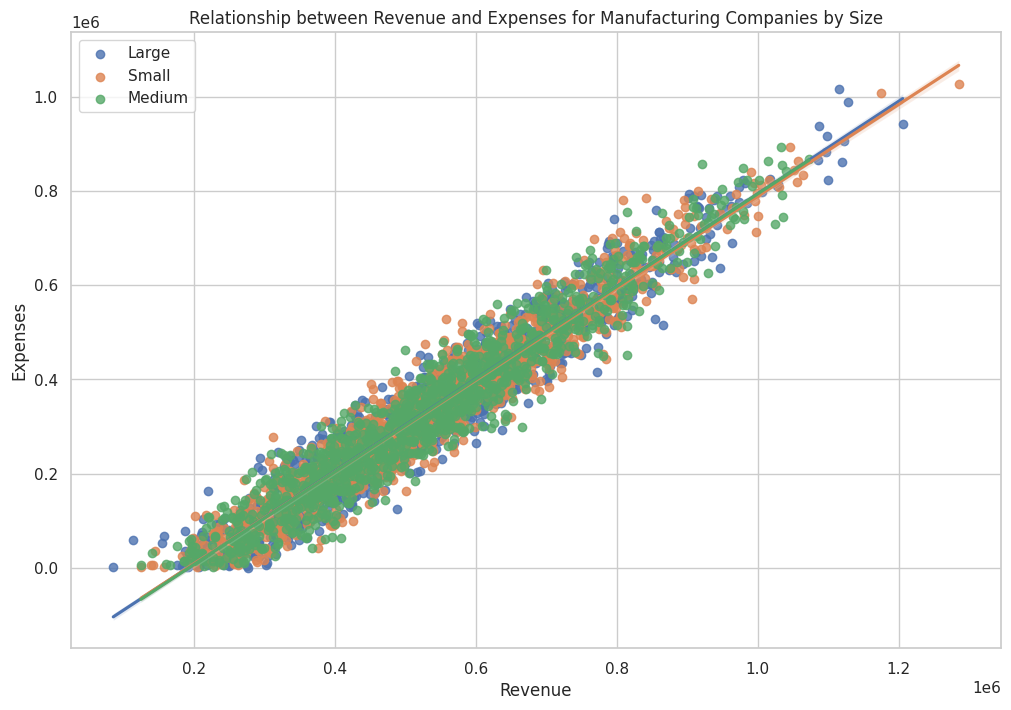

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Filter manufacturing companies
manufacturing_df = df[df['Industry'] == 'Manufacturing']

# Get unique company sizes
company_sizes = manufacturing_df['Company_Size'].unique()

# Set the figure size
plt.figure(figsize=(12, 8))

for size in company_sizes:
    sub_df = manufacturing_df[manufacturing_df['Company_Size'] == size]
    sns.regplot(x='Revenue', y='Expenses', data = sub_df, label = size)

plt.title('Relationship between Revenue and Expenses for Manufacturing Companies by Size')
plt.xlabel('Revenue')
plt.ylabel('Expenses')
plt.legend()
plt.show()